<a href="https://colab.research.google.com/github/expaetra/CM3070_final_project/blob/master/13_optuna_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/expaetra/CM3070_final_project.git
%cd CM3070_final_project

Cloning into 'CM3070_final_project'...
remote: Enumerating objects: 248, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 248 (delta 73), reused 46 (delta 17), pack-reused 129 (from 1)
Receiving objects: 100% (248/248), 71.10 MiB | 17.27 MiB/s, done.
Resolving deltas: 100% (111/111), done.
Updating files: 100% (64/64), done.
/content/CM3070_final_project/CM3070_final_project/CM3070_final_project


In [ ]:
!pip install optuna -q

Optuna was used to automatically tune the hyperparameters of the Logistic Regression model. It optimizes performance by running multiple trials and tests a different combination of parameters.

In [55]:
import pandas as pd
import numpy as np
import nltk
import optuna
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
# load dataset

df = pd.read_csv("/content/arxiv_abstracts_and_titles.csv")
print(df.shape)
df.head()

(79141, 7)


,category,field,discipline,title,abstract,abstract_length,title_length
0,cs.LG,Machine Learning,Artificial Intelligence,how do lexical semantics affect translation an...,neural machine translation (nmt) systems aim t...,177,9
1,cs.LG,Machine Learning,Artificial Intelligence,barack partially supervised group robustness w...,while neural networks have shown remarkable su...,203,7
2,cs.LG,Machine Learning,Artificial Intelligence,a deep learning approach to integrate humanlev...,"in recent times, a large number of people have...",187,11
3,cs.LG,Machine Learning,Artificial Intelligence,croesus multistage processing and transactions...,emerging edge applications require both a fast...,194,10
4,cs.LG,Machine Learning,Artificial Intelligence,representation topology divergence a method fo...,comparison of data representations is a comple...,133,10


In [ ]:
# cap the outlieers for clas balance

cap = 2500

df_capped = (
    df.groupby('discipline', group_keys=False)[df.columns]
      .apply(lambda x: x.sample(n=min(len(x), cap), random_state=42))
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print(df_capped['discipline'].value_counts())

discipline
Information Retrieval           2500
Multimedia                      2500
Computer Graphics               2500
Computer Imaging and Vision     2500
Cybersecurity                   2500
Theory of Computation           2500
Communication                   2500
Database Systems                2500
Artificial Intelligence         2500
Computer Hardware               2500
World Wide Web                  2500
Robotics                        2500
Computer Networks               2500
Human-Computer Interaction      2499
Computational Science           2499
Social Computing                2499
Distributed Systems             2498
Software Engineering            2494
Computer Programming            2486
Emerging Technologies           2474
Theoretical Computer Science    2301
Computer Systems                2176
Name: count, dtype: int64


In [ ]:
# apply custom stopwords

nltk.download("stopwords")

custom_stops = {
    'based', 'paper', 'show', 'results', 'problem', 'using', 'approach',
    'proposed', 'method', 'methods', 'propose', 'present', 'work',
    'used', 'use', 'two', 'one', 'new', 'also', 'shows', 'however',
    'provide', 'study', 'task', 'tasks', 'different', 'high', 'given'
}
stop_words = set(stopwords.words('english')).union(custom_stops)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#  weigthed titles

def build_weighted_text(title_series, abstract_series, title_weight):
    return ((title_series.astype(str) + " ") * title_weight + abstract_series.astype(str)).astype(str)

In [ ]:
# evaluation

def get_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "Macro Precision": macro_p,
        "Macro Recall": macro_r,
        "Macro F1": macro_f1,
        "Weighted Precision": weighted_p,
        "Weighted Recall": weighted_r,
        "Weighted F1": weighted_f1
    }

In [ ]:
# get titles, abstract, labels, for discipline

title_disc = df_capped["title"]
abstract_disc = df_capped["abstract"]
y_disc = df_capped["discipline"]

disc_idx = np.arange(len(df_capped))

disc_train_idx, disc_val_idx, y_disc_train, y_disc_val = train_test_split(
    disc_idx,
    y_disc,
    test_size=0.2,
    random_state=42,
    stratify=y_disc
)

In [ ]:
# fields

title_field = df["title"]
abstract_field = df["abstract"]
y_field = df["field"]

field_idx = np.arange(len(df))

field_train_idx, field_val_idx, y_field_train, y_field_val = train_test_split(
    field_idx,
    y_field,
    test_size=0.2,
    random_state=42,
    stratify=y_field
)

In [ ]:
# hyperparameters selection for discipline

def discipline_objective(trial):
    title_weight = trial.suggest_int("title_weight", 1, 3) # how important the title is
    ngram_max = trial.suggest_categorical("ngram_max", [1,2]) #unigrams or bigrams
    max_features = trial.suggest_categorical("max_features", [10000, 15000]) #vocabylary size
    C = trial.suggest_categorical("C", [1, 2, 4, 8]) # regularization
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"]) # handlign imbalance

    # combine title + abstarct
    X_train_text = build_weighted_text(
        title_disc.iloc[disc_train_idx],
        abstract_disc.iloc[disc_train_idx],
        title_weight
    )

    X_val_text = build_weighted_text(
        title_disc.iloc[disc_val_idx],
        abstract_disc.iloc[disc_val_idx],
        title_weight
    )

    #  tfidf
    vectorizer = TfidfVectorizer(
        stop_words=list(stop_words),
        ngram_range=(1, ngram_max),
        max_features=max_features
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_val = vectorizer.transform(X_val_text)


    # train LogReg
    model = LogisticRegression(
        C=C,
        class_weight=class_weight,
        solver="liblinear",
        max_iter=3000,
        random_state=42
    )

    model.fit(X_train, y_disc_train)
    y_pred = model.predict(X_val)

    metrics =get_metrics(y_disc_val, y_pred)
    return metrics["Macro F1"]

In [ ]:
def field_objective(trial):
    title_weight = trial.suggest_int("title_weight", 1, 3)
    ngram_max = trial.suggest_categorical("ngram_max", [1, 2])
    max_features = trial.suggest_categorical("max_features", [10000,15000])
    C = trial.suggest_categorical("C", [1, 2, 4, 8])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    X_train_text = build_weighted_text(
        title_field.iloc[field_train_idx],
        abstract_field.iloc[field_train_idx],
        title_weight
    )

    X_val_text = build_weighted_text(
        title_field.iloc[field_val_idx],
        abstract_field.iloc[field_val_idx],
        title_weight
    )

    vectorizer = TfidfVectorizer(
        stop_words=list(stop_words),
        ngram_range=(1, ngram_max),
        max_features=max_features
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_val = vectorizer.transform(X_val_text)

    model = LogisticRegression(
        C=C,
        class_weight=class_weight,
        solver="liblinear",
        max_iter=3000,
        random_state=42
    )

    model.fit(X_train, y_field_train)
    y_pred = model.predict(X_val)

    metrics = get_metrics(y_field_val, y_pred)
    return metrics["Macro F1"]

In [34]:
study_disc = optuna.create_study(direction="maximize")
study_disc.optimize(discipline_objective, n_trials=20)

print("Best discipline params:")
print(study_disc.best_params)
print("Best discipline Macro F1:", study_disc.best_value)

[I 2026-03-23 07:26:01,122] A new study created in memory with name: no-name-6181e116-b943-4b86-9442-69dbcb14ed0a
[I 2026-03-23 07:27:27,652] Trial 0 finished with value: 0.6247090028438956 and parameters: {'title_weight': 3, 'ngram_max': 2, 'max_features': 15000, 'C': 2, 'class_weight': None}. Best is trial 0 with value: 0.6247090028438956.
[I 2026-03-23 07:29:08,919] Trial 1 finished with value: 0.5954150439420722 and parameters: {'title_weight': 2, 'ngram_max': 2, 'max_features': 10000, 'C': 8, 'class_weight': None}. Best is trial 0 with value: 0.6247090028438956.
[I 2026-03-23 07:30:20,532] Trial 2 finished with value: 0.6287434528056633 and parameters: {'title_weight': 1, 'ngram_max': 2, 'max_features': 10000, 'C': 1, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.6287434528056633.
[I 2026-03-23 07:31:43,115] Trial 3 finished with value: 0.6240197898390399 and parameters: {'title_weight': 1, 'ngram_max': 2, 'max_features': 10000, 'C': 2, 'class_weight': None}. Best is 

Best discipline params:
{'title_weight': 3, 'ngram_max': 2, 'max_features': 15000, 'C': 1, 'class_weight': 'balanced'}
Best discipline Macro F1: 0.629895229713838


In [35]:
study_field = optuna.create_study(direction="maximize")
study_field.optimize(field_objective, n_trials=20)

print("Best field params:")
print(study_field.best_params)
print("Best field Macro F1:", study_field.best_value)

[I 2026-03-23 07:52:26,266] A new study created in memory with name: no-name-7d5a84ed-6d6c-4cce-8599-8c46ee9e5b62
[I 2026-03-23 07:54:48,915] Trial 0 finished with value: 0.5328136029136634 and parameters: {'title_weight': 2, 'ngram_max': 1, 'max_features': 10000, 'C': 2, 'class_weight': None}. Best is trial 0 with value: 0.5328136029136634.
[I 2026-03-23 07:58:11,445] Trial 1 finished with value: 0.4951804078226387 and parameters: {'title_weight': 3, 'ngram_max': 2, 'max_features': 10000, 'C': 8, 'class_weight': None}. Best is trial 0 with value: 0.5328136029136634.
[I 2026-03-23 08:00:48,487] Trial 2 finished with value: 0.5302324446475195 and parameters: {'title_weight': 3, 'ngram_max': 2, 'max_features': 10000, 'C': 2, 'class_weight': None}. Best is trial 0 with value: 0.5328136029136634.
[I 2026-03-23 08:03:08,515] Trial 3 finished with value: 0.5328136029136634 and parameters: {'title_weight': 2, 'ngram_max': 1, 'max_features': 10000, 'C': 2, 'class_weight': None}. Best is trial 

Best field params:
{'title_weight': 2, 'ngram_max': 1, 'max_features': 10000, 'C': 1, 'class_weight': 'balanced'}
Best field Macro F1: 0.5407887012574948


In [51]:
# train final model using best optuna params
# train final model using best Optuna params
def train_best_model(best_params, title, abstract, train_idx, val_idx, y_train):
    X_train_text = build_weighted_text(
        title.iloc[train_idx],
        abstract.iloc[train_idx],
        best_params["title_weight"]
    )

    X_val_text = build_weighted_text(
        title.iloc[val_idx],
        abstract.iloc[val_idx],
        best_params["title_weight"]
    )

    vectorizer = TfidfVectorizer(
        stop_words=list(stop_words),
        ngram_range=(1, best_params["ngram_max"]),
        max_features=best_params["max_features"]
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_val = vectorizer.transform(X_val_text)

    model = LogisticRegression(
        C=best_params["C"],
        class_weight=best_params["class_weight"],
        solver="liblinear",
        max_iter=3000,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    return model, vectorizer, y_pred

In [52]:
# get predictions

# discipline
model_disc, vectorizer_disc, y_pred_disc = train_best_model(
    study_disc.best_params,
    title_disc,
    abstract_disc,
    disc_train_idx,
    disc_val_idx,
    y_disc_train
)

# field
model_field, vectorizer_field, y_pred_field = train_best_model(
    study_field.best_params,
    title_field,
    abstract_field,
    field_train_idx,
    field_val_idx,
    y_field_train
)

In [54]:
print(type(y_pred_disc), len(y_pred_disc), len(y_disc_val))
print(type(y_pred_field), len(y_pred_field), len(y_field_val))



<class 'numpy.ndarray'> 10886 10886
<class 'numpy.ndarray'> 15829 15829


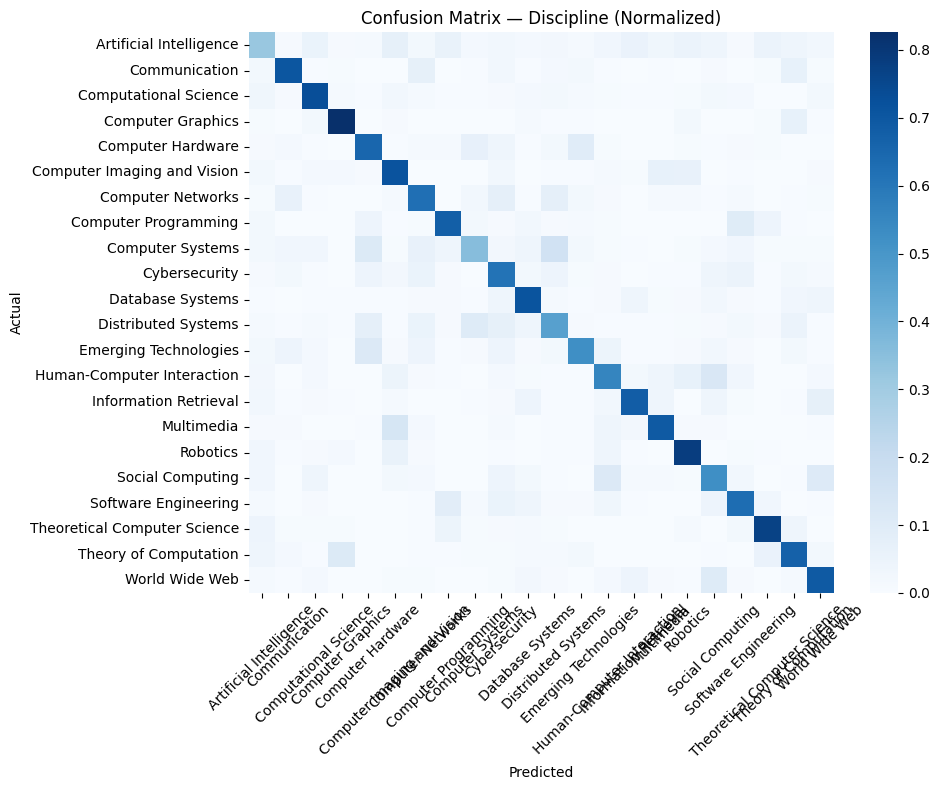

In [56]:
labels_disc = sorted(y_disc_val.unique())

cm_disc = confusion_matrix(y_disc_val, y_pred_disc, labels=labels_disc)
cm_disc = cm_disc.astype(float) / cm_disc.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_disc, cmap="Blues", xticklabels=labels_disc, yticklabels=labels_disc)
plt.title("Confusion matrix: discipline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


labels_field = sorted(y_field_val.unique())

cm_field = confusion_matrix(y_field_val, y_pred_field, labels=labels_field)
cm_field = cm_field.astype(float) / cm_field.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_field, cmap="Greens",xticklabels=labels_field, yticklabels=labels_field)
plt.title("Confusion matrix: field")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
disc_metrics = get_metrics(y_disc_val, y_pred_disc)
field_metrics = get_metrics(y_field_val, y_pred_field)

In [46]:
optuna_results = pd.DataFrame([
    {"Task": "Discipline", **{k: round(v, 3) for k, v in disc_metrics.items()}},
    {"Task": "Field", **{k: round(v, 3) for k, v in field_metrics.items()}}
])

optuna_results

,Task,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,0.634,0.631,0.633,0.630,0.631,0.634,0.631
1,Field,0.549,0.537,0.549,0.541,0.537,0.549,0.540


In [58]:
print(len(y_disc_val), len(y_pred_disc))
print(len(y_field_val), len(y_pred_field))

10886 10886
15829 15829


In [59]:
disc_results = pd.DataFrame({
    "discipline": list(y_disc_val),
    "pred_discipline": list(y_pred_disc)
})

field_results = pd.DataFrame({
    "field": list(y_field_val),
    "pred_field": list(y_pred_field)
})

disc_results.to_csv("disc_predictions.csv", index=False)
field_results.to_csv("field_predictions.csv", index=False)

print("Predictions saved")

Predictions saved


In [60]:
# save
import os
import joblib

os.makedirs("/content/drive/MyDrive/CM3070_final_project/backend/data", exist_ok=True)

optuna_results.to_csv(
    "/content/drive/MyDrive/CM3070_final_project/backend/data/optuna_results.csv",
    index=False
)


import joblib

joblib.dump(model_disc, "logreg_disc_optuna.pkl")
joblib.dump(vectorizer_disc, "tfidf_disc_optuna.pkl")

joblib.dump(model_field, "logreg_field_optuna.pkl")
joblib.dump(vectorizer_field, "tfidf_field_optuna.pkl")

print("Models saved")

print("Saved")

Models saved
Saved
